In [1]:
import os
import numpy as np
from sklearn.cluster import SpectralClustering
import cvxpy as cp
import mosek
import src.opt as opt
import src.utils as utils

SAVE = True
PREFIX = './results/opt_lamb_araus'

# Check restuls dir exists and create
if not os.path.exists(PREFIX):
    os.makedirs(PREFIX)

## Load and plot data

Original Y shape: (9, 20022). Keeping only the first 2 rows.
Shape of: X: (143, 20022)  -  Y: (2, 20022)  -  data: (145, 20022)
(Min, Max) values of: X: (-9.194, 24.975)  - Y: (1.000, 5.000)  -  data: (-9.194, 24.975)
Mean value of: X: -0.000  -  Y: 2.924  -  data: 0.040
Std value of: X: 1.000  -  Y: 1.137  -  data: 1.058


<Figure size 900x600 with 0 Axes>

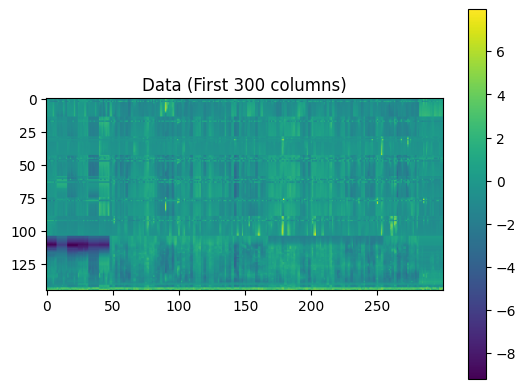

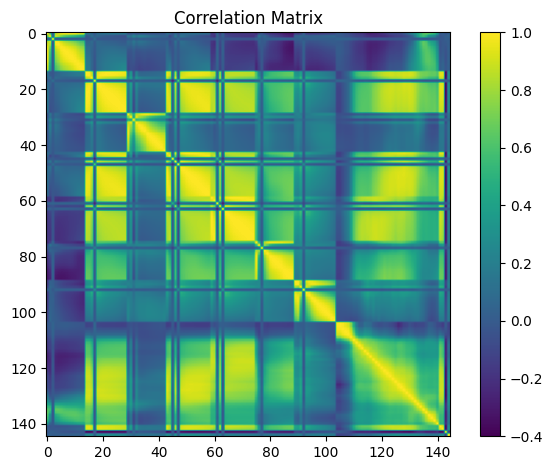

In [2]:
Data = utils.load_accoustic_data(path_data='data/ARAUS/', y_filename='Y_mean.mat', x_key='X', y_key='Y', all_data=False)
N, M = Data.shape

## Learn undirected SEM with negative edges

In [3]:
# Estimate A
lamb0 = np.sqrt(np.log(N)/M)

Mults = np.concatenate( [np.linspace(0, 250, 15), np.linspace(300, 750, 15), np.linspace(1000, 5000, 10)] )
A_undir_sem = []
S = Data @ Data.T
w, v = np.linalg.eigh(S)
B = v @ np.diag(np.sqrt(np.maximum(w, 0)))

for mult in Mults:
    lamb = mult*lamb0

    A_est = opt.sparse_id(B, lamb, use_cov=True, symmetric=True,  verbose=False)

    norm_A = np.linalg.norm(A_est.flatten(), 1)

    print(f'Lamb (mult): {lamb:.4f} ({mult})  - norm A: {norm_A:.4f}')

    A_undir_sem.append(A_est)
    


Lamb (mult): 0.0000 (0.0)  - norm A: 600.2016
Lamb (mult): 0.2815 (17.857142857142858)  - norm A: 268.8809
Lamb (mult): 0.5631 (35.714285714285715)  - norm A: 226.4835
Lamb (mult): 0.8446 (53.57142857142857)  - norm A: 205.8955
Lamb (mult): 1.1261 (71.42857142857143)  - norm A: 192.6536
Lamb (mult): 1.4077 (89.28571428571429)  - norm A: 183.2448
Lamb (mult): 1.6892 (107.14285714285714)  - norm A: 176.2268
Lamb (mult): 1.9707 (125.0)  - norm A: 170.8039
Lamb (mult): 2.2523 (142.85714285714286)  - norm A: 166.5735
Lamb (mult): 2.5338 (160.71428571428572)  - norm A: 163.0614
Lamb (mult): 2.8153 (178.57142857142858)  - norm A: 160.1916
Lamb (mult): 3.0969 (196.42857142857144)  - norm A: 157.8194
Lamb (mult): 3.3784 (214.28571428571428)  - norm A: 155.7961
Lamb (mult): 3.6599 (232.14285714285714)  - norm A: 154.0852
Lamb (mult): 3.9415 (250.0)  - norm A: 152.6519
Lamb (mult): 4.7298 (300.0)  - norm A: 149.7013
Lamb (mult): 5.2365 (332.14285714285717)  - norm A: 148.2147
Lamb (mult): 5.7433 

In [4]:
# # # Load and plot
# file_name = f'{PREFIX}/sem_und_withth_err.npz'
# data = np.load(file_name)
# err = data['err']
# sparsity = data['sparsity']
# lambdas = data['lambdas']
# lamb0 = np.sqrt(np.log(N)/M)
# Mults = lambdas/lamb0   
# utils.save_plot_err_sparsity(lambdas, err, sparsity, file_name=file_name, save=False)

# file_name = f'{PREFIX}/sem_und_withth_err.npz'
# data = np.load(file_name)
# err = data['err']
# sparsity = data['sparsity']
# lambdas = data['lambdas']
# lamb0 = np.sqrt(np.log(N)/M)
# Mults = lambdas/lamb0  
# utils.save_plot_err_sparsity(lambdas, err, sparsity, title='Error - Outputs', file_name=file_name+'_out', save=False)


### Plot error without thresholding

Max number of links: 10440.0


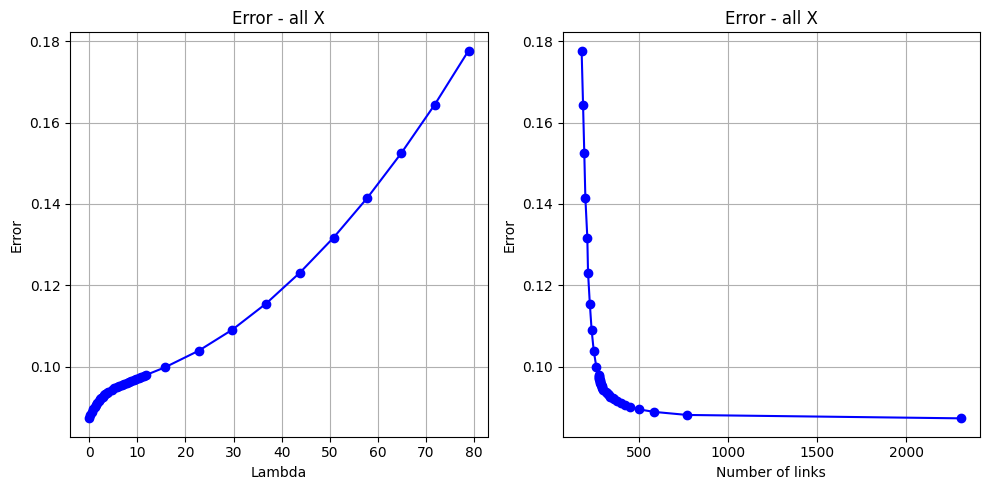

	 Saved as: ./results/opt_lamb_araus/sem_und_withth_err
Max number of links: 287


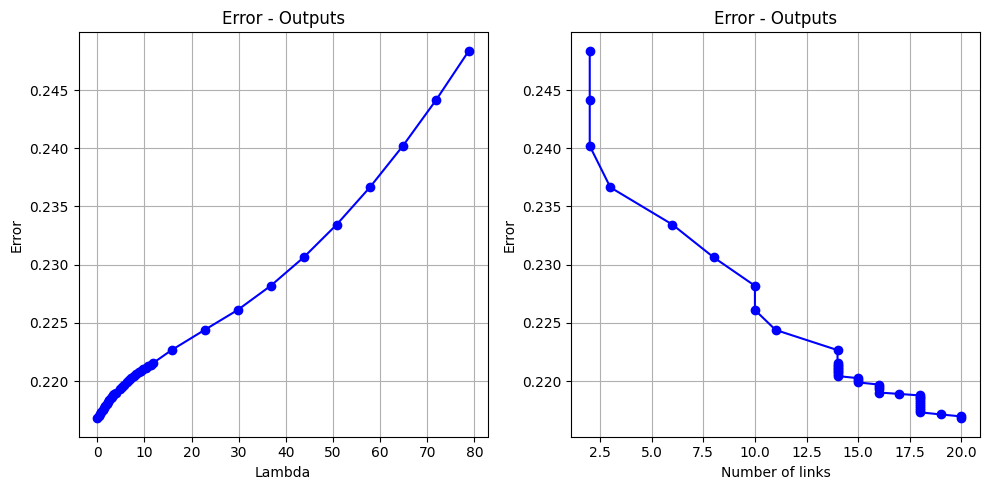

	 Saved as: ./results/opt_lamb_araus/sem_und_withth_err_out


In [ ]:
th = 0.03
lambdas = Mults*lamb0
N = Data.shape[0]

file_name = f'{PREFIX}/sem_und_withth_err'

## For all variables
print('Max number of links:', N*(N-1)/2)
err, sparsity = utils.compute_err_sparsity(A_undir_sem, Data, th, th_err=False)
utils.save_plot_err_sparsity(lambdas, err, sparsity, file_name=file_name, save=SAVE)

## For output variables
target = np.arange(143,145)
print('Max number of links:', 2*(N-1)-1)
err, sparsity = utils.compute_err_sparsity(A_undir_sem, Data, th, th_err=False, target_idx=target)
utils.save_plot_err_sparsity(lambdas, err, sparsity, title='Error - Outputs', file_name=file_name+'_out', save=SAVE)


Max number of links: 10440.0


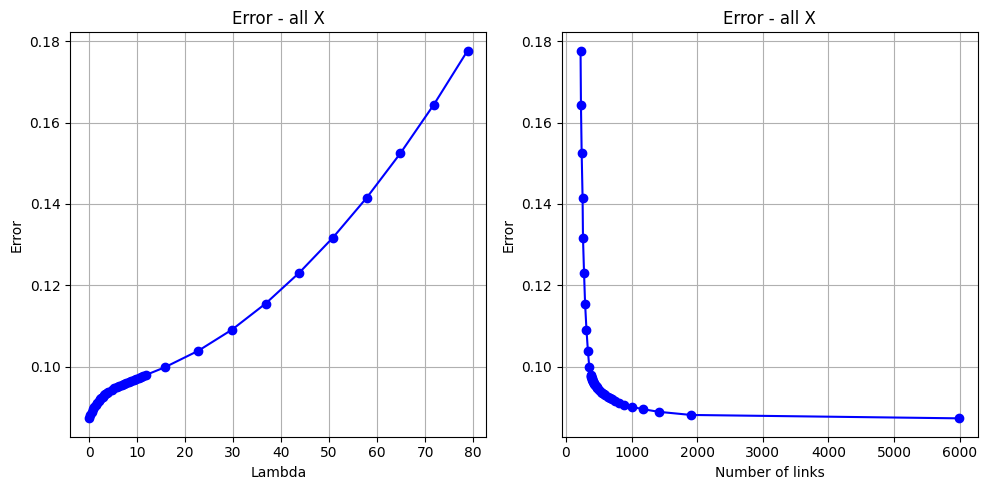

	 Saved as: ./results/opt_lamb_araus/sem_und_withth_err
Max number of links: 287


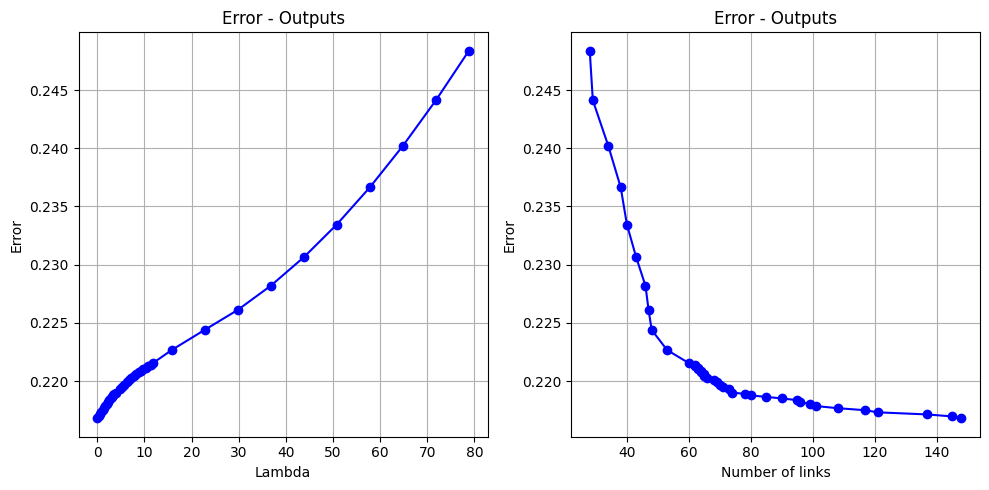

	 Saved as: ./results/opt_lamb_araus/sem_und_withth_err_out


In [13]:
th = 0.01
lambdas = Mults*lamb0
N = Data.shape[0]

file_name = f'{PREFIX}/sem_und_withth_err'

## For all variables
print('Max number of links:', N*(N-1)/2)
err, sparsity = utils.compute_err_sparsity(A_undir_sem, Data, th, th_err=False)
utils.save_plot_err_sparsity(lambdas, err, sparsity, file_name=file_name, save=SAVE)

## For output variables
target = np.arange(143,145)
print('Max number of links:', 2*(N-1)-1)
err, sparsity = utils.compute_err_sparsity(A_undir_sem, Data, th, th_err=False, target_idx=target)
utils.save_plot_err_sparsity(lambdas, err, sparsity, title='Error - Outputs', file_name=file_name+'_out', save=SAVE)


In [7]:
# import pandas as pd

# # files = ['sem_und_noth_err_out', 'sem_und_noth_err_out122', 'sem_und_noth_err_out123', 'sem_und_noth_err',
# #          'sem_und_withth_err_out', 'sem_und_withth_err_out122', 'sem_und_withth_err_out123', 'sem_und_withth_err']
# files = ['sem_und_noth_err_out', 'sem_und_noth_err', 'sem_und_withth_err']
# for sufix in files:
#     file_name = PREFIX + '/' + sufix + '.npz'
#     lamb0 = np.sqrt(np.log(N)/M)
#     data = np.load(file_name)  # O "file.npz" si usaste esa extensión

#     err = data['err']
#     sparsity = data['sparsity']
#     lambdas = data['lambdas']

#     df = pd.DataFrame({key: data[key] for key in data.files})
#     csv_file = PREFIX + '/' + sufix + '.csv'
#     df.to_csv(csv_file, index=False)
#     print(csv_file)


## Learn unconnected SEM with negative edges

In [8]:
# Estimate A
lamb0 = np.sqrt(np.log(N)/M)

Mults = np.concatenate( [np.linspace(0, 250, 15), np.linspace(300, 750, 15), np.linspace(1000, 5000, 10)] )
A_undir_sem2 = []
S = Data @ Data.T
w, v = np.linalg.eigh(S)
B = v @ np.diag(np.sqrt(np.maximum(w, 0)))

for mult in Mults:
    lamb = mult*lamb0

    A_est = opt.sparse_id(B, lamb, symmetric=True, use_cov=True, zero_indices=[[-1,-2]], verbose=False)

    norm_A = np.linalg.norm(A_est.flatten(), 1)

    print(f'Lamb (mult): {lamb:.4f} ({mult}) - norm A: {norm_A:.4f}')

    A_undir_sem2.append(A_est)
    


Lamb (mult): 0.0000 (0.0) - norm A: 596.0262
Lamb (mult): 0.2815 (17.857142857142858) - norm A: 264.5262
Lamb (mult): 0.5631 (35.714285714285715) - norm A: 222.1801
Lamb (mult): 0.8446 (53.57142857142857) - norm A: 201.7162
Lamb (mult): 1.1261 (71.42857142857143) - norm A: 188.5629
Lamb (mult): 1.4077 (89.28571428571429) - norm A: 179.2016
Lamb (mult): 1.6892 (107.14285714285714) - norm A: 172.2581
Lamb (mult): 1.9707 (125.0) - norm A: 166.9211
Lamb (mult): 2.2523 (142.85714285714286) - norm A: 162.7648
Lamb (mult): 2.5338 (160.71428571428572) - norm A: 159.3303
Lamb (mult): 2.8153 (178.57142857142858) - norm A: 156.5919
Lamb (mult): 3.0969 (196.42857142857144) - norm A: 154.2650
Lamb (mult): 3.3784 (214.28571428571428) - norm A: 152.2766
Lamb (mult): 3.6599 (232.14285714285714) - norm A: 150.6318
Lamb (mult): 3.9415 (250.0) - norm A: 149.2580
Lamb (mult): 4.7298 (300.0) - norm A: 146.4021
Lamb (mult): 5.2365 (332.14285714285717) - norm A: 144.9748
Lamb (mult): 5.7433 (364.285714285714

### Plot error without thresholding

Max number of links: 10440.0
Number of links (whole graph):
[5906. 1815. 1337. 1107.  928.  824.  751.  692.  647.  611.  585.  551.
  527.  510.  491.  457.  439.  426.  415.  403.  391.  381.  376.  372.
  365.  364.  358.  354.  351.  346.  332.  309.  285.  259.  242.  227.
  215.  207.  202.  198.]


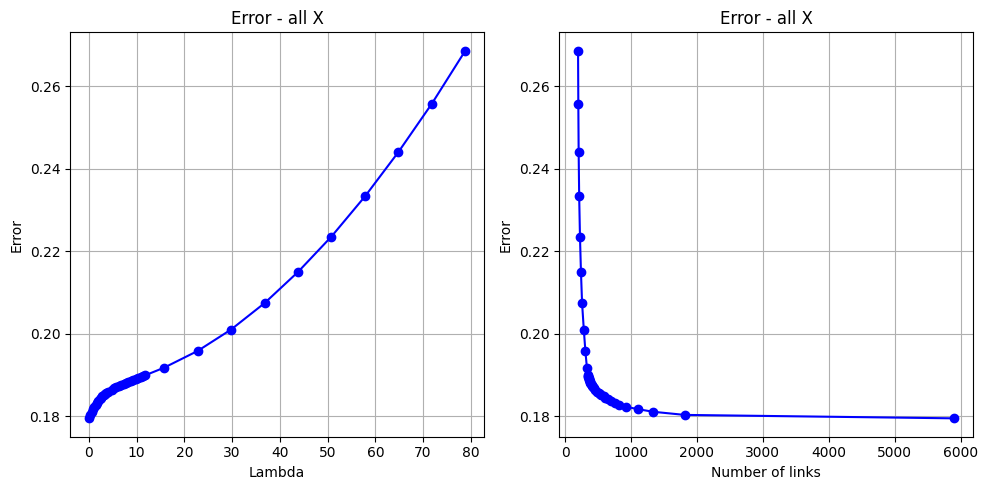

	 Saved as: ./results/opt_lamb_araus/sem_unc_noth_err
Max number of links: 287
Number of links (only output):
[59. 51. 46. 44. 40. 37. 37. 36. 36. 34. 32. 32. 30. 31. 31. 29. 28. 29.
 29. 28. 26. 26. 25. 24. 25. 25. 23. 23. 23. 23. 24. 20. 17. 11.  8.  3.
  0.  0.  0.  0.]


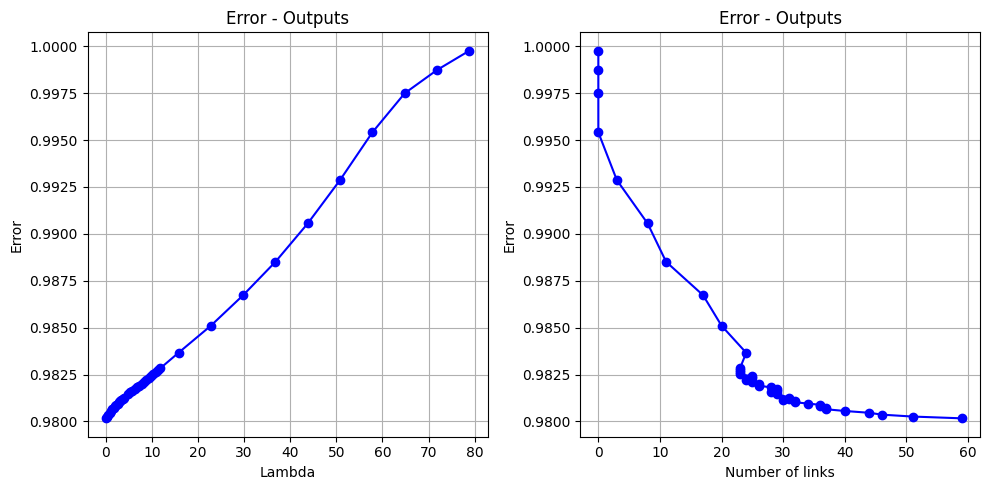

	 Saved as: ./results/opt_lamb_araus/sem_unc_noth_err_out


In [16]:
th = 0.01
lambdas = Mults*lamb0
N = Data.shape[0]

file_name = f'{PREFIX}/sem_unc_noth_err'

## For all variables
print('Max number of links:', N*(N-1)/2)
err, sparsity = utils.compute_err_sparsity(A_undir_sem2, Data, th, th_err=False)
print('Number of links (whole graph):')
print(sparsity)

utils.save_plot_err_sparsity(lambdas, err, sparsity, file_name=file_name, save=SAVE)

## For output variables
target = np.arange(143,145)
print('Max number of links:', 2*(N-1)-1)
err, sparsity = utils.compute_err_sparsity(A_undir_sem2, Data, th, th_err=False, target_idx=target)

print('Number of links (only output):')
print(sparsity)

utils.save_plot_err_sparsity(lambdas, err, sparsity, title='Error - Outputs', file_name=file_name+'_out', save=SAVE)